# Otimização de rotas (campus / carregadores)

**Especificações do cenário (modelo físico):**
- **20** containers no total.
- **Embarcação:** grade **4×4** (linhas × colunas) por piso (layout do navio miniatura).
- **Píer:** grade **5×2** (linhas × colunas); com **2 níveis** de empilhamento no simulador do descarregamento isso corresponde a **20** posições no píer — capacidade compatível com os 20 containers.

Esta parte trata só da **entrega no campus** (carregadores), em separado do AG do barco. Entrada típica: lista de entregas com **tempo em que cada container fica disponível no píer** (`ready_time`), vindo da sequência de descarregamento (produtor). O **exemplo** ao final usa **20 entregas** (`container_id` 0 a 19), alinhado ao enunciado; substitua `ready` e destinos pelos valores vindos da simulação real quando integrar.

- **Produtor:** descarregamento libera containers no píer ao longo do tempo.
- **Consumidor:** carregadores buscam no píer, entregam no destino; entre uma entrega e outra voltam ao píer.
- **Objetivo:** minimizar o **makespan** (instante em que a última entrega termina).

O AG evolui uma **permutação** (prioridade das tarefas); a decodificação atribui cada tarefa ao carregador que a conclui mais cedo naquele momento.


In [21]:
import copy
import random
from dataclasses import dataclass, field
from statistics import mean
from typing import Sequence

import matplotlib.pyplot as plt


### Estruturas e tempos de viagem


In [22]:
@dataclass
class DeliveryTask:
    """Uma entrega: container, destino no grafo, disponível no píer em ready_time."""

    container_id: int
    destination: int
    ready_time: float = 0.0


@dataclass
class CarrierEvent:
    t_start: float
    t_end: float
    kind: str
    detail: str


@dataclass
class CarrierSchedule:
    carrier_id: int
    task_indices: list[int]
    events: list[CarrierEvent] = field(default_factory=list)
    finish_time: float = 0.0


@dataclass
class RouteSolution:
    schedules: list[CarrierSchedule]
    makespan: float
    total_travel_time: float
    permutation: list[int] | None = None


class TravelTimeModel:
    """Índice 0 = píer; travel[i,j] = tempo de i até j (mesmas unidades que ready_time)."""

    def __init__(self, travel_matrix: Sequence[Sequence[float]]):
        rows = [[float(x) for x in row] for row in travel_matrix]
        n = len(rows)
        if n == 0 or any(len(r) != n for r in rows):
            raise ValueError("travel_matrix deve ser quadrada e não vazia")
        self.matrix = rows
        self.n = n

    def time(self, origin: int, dest: int) -> float:
        return self.matrix[origin][dest]

    @staticmethod
    def from_symmetric_distances(
        distances: Sequence[Sequence[float]], speed: float = 1.0
    ) -> "TravelTimeModel":
        spd = float(speed)
        t = [
            [float(distances[i][j]) / spd for j in range(len(distances[i]))]
            for i in range(len(distances))
        ]
        return TravelTimeModel(t)


PIER = 0


### Atribuição por permutação e simulação das rotas


In [23]:
def _assign_tasks_greedy_by_permutation(
    perm: list[int],
    tasks: list[DeliveryTask],
    travel: TravelTimeModel,
    num_carriers: int,
) -> tuple[list[list[int]], float]:
    n = len(tasks)
    if n == 0:
        return [[] for _ in range(num_carriers)], 0.0

    t_free = [0.0] * num_carriers
    position = [PIER] * num_carriers
    routes: list[list[int]] = [[] for _ in range(num_carriers)]

    for idx in perm:
        task = tasks[idx]
        dest = task.destination
        best_c = 0
        best_finish = float("inf")

        for c in range(num_carriers):
            pos = position[c]
            t0 = t_free[c]
            t_at_pier = t0 + travel.time(pos, PIER)
            t_after_wait = max(t_at_pier, task.ready_time)
            t_finish = t_after_wait + travel.time(PIER, dest)
            if t_finish < best_finish:
                best_finish = t_finish
                best_c = c

        c = best_c
        pos = position[c]
        t0 = t_free[c]
        t_at_pier = t0 + travel.time(pos, PIER)
        t_after_wait = max(t_at_pier, task.ready_time)
        t_finish = t_after_wait + travel.time(PIER, dest)

        routes[c].append(idx)
        t_free[c] = t_finish
        position[c] = dest

    makespan = max(t_free) if t_free else 0.0
    return routes, makespan


def simulate_routes(
    tasks: list[DeliveryTask],
    travel: TravelTimeModel,
    routes: list[list[int]],
) -> RouteSolution:
    num_carriers = len(routes)
    schedules: list[CarrierSchedule] = []
    total_travel = 0.0

    for c in range(num_carriers):
        events: list[CarrierEvent] = []
        t = 0.0
        pos = PIER
        route = routes[c]

        for task_idx in route:
            task = tasks[task_idx]
            dest = task.destination

            t_move_pier = t + travel.time(pos, PIER)
            total_travel += travel.time(pos, PIER)
            events.append(CarrierEvent(t, t_move_pier, "deslocamento", f"{pos}→{PIER}"))

            t_at_pier = t_move_pier
            if t_at_pier < task.ready_time:
                events.append(
                    CarrierEvent(
                        t_at_pier,
                        task.ready_time,
                        "espera",
                        f"container {task.container_id} (ready {task.ready_time})",
                    )
                )
                t_at_pier = task.ready_time

            t_arrive_dest = t_at_pier + travel.time(PIER, dest)
            total_travel += travel.time(PIER, dest)
            events.append(
                CarrierEvent(t_at_pier, t_arrive_dest, "deslocamento", f"{PIER}→{dest}")
            )
            events.append(
                CarrierEvent(
                    t_arrive_dest,
                    t_arrive_dest,
                    "entrega",
                    f"container {task.container_id} → destino {dest}",
                )
            )
            t = t_arrive_dest
            pos = dest

        schedules.append(
            CarrierSchedule(
                carrier_id=c,
                task_indices=list(route),
                events=events,
                finish_time=t,
            )
        )

    makespan = max(s.finish_time for s in schedules) if schedules else 0.0
    return RouteSolution(
        schedules=schedules,
        makespan=makespan,
        total_travel_time=total_travel,
        permutation=None,
    )


### Algoritmo genético (permutação + OX)


In [24]:
def _permutation_ox(p1: list[int], p2: list[int]) -> tuple[list[int], list[int]]:
    n = len(p1)
    if n < 2:
        return p1[:], p2[:]
    a, b = sorted(random.sample(range(n), 2))

    def ox(a, b, p1, p2):
        hole = set(p1[a : b + 1])
        child = [None] * n
        child[a : b + 1] = p1[a : b + 1]
        fill = [x for x in p2 if x not in hole]
        j = 0
        for i in list(range(0, a)) + list(range(b + 1, n)):
            child[i] = fill[j]
            j += 1
        return child

    return ox(a, b, p1, p2), ox(a, b, p2, p1)


class RouteOptimizerGA:
    def __init__(
        self,
        tasks: list[DeliveryTask],
        travel: TravelTimeModel,
        num_carriers: int,
        population_size: int = 80,
        generations: int = 150,
        p_crossover: float = 0.85,
        p_mutation: float = 0.15,
        elitism: int = 2,
        rng: random.Random | None = None,
    ):
        self.tasks = tasks
        self.travel = travel
        self.num_carriers = max(1, num_carriers)
        self.population_size = population_size
        self.generations = generations
        self.p_crossover = p_crossover
        self.p_mutation = p_mutation
        self.elitism = min(elitism, population_size)
        self.rng = rng or random.Random()
        self.n = len(tasks)
        self._indices = list(range(self.n))

    def _fitness(self, perm: list[int]) -> float:
        _, makespan = _assign_tasks_greedy_by_permutation(
            perm, self.tasks, self.travel, self.num_carriers
        )
        return 1.0 / (makespan + 1e-9)

    def _random_individual(self) -> list[int]:
        ind = self._indices[:]
        self.rng.shuffle(ind)
        return ind

    def _mutate(self, perm: list[int]) -> None:
        if self.n < 2:
            return
        if self.rng.random() < 0.5:
            i, j = self.rng.sample(range(self.n), 2)
            perm[i], perm[j] = perm[j], perm[i]
        else:
            i, j = sorted(self.rng.sample(range(self.n), 2))
            perm[i : j + 1] = reversed(perm[i : j + 1])

    def run(self) -> tuple[RouteSolution, list[float], list[float]]:
        if self.n == 0:
            empty = RouteSolution(
                schedules=[], makespan=0.0, total_travel_time=0.0, permutation=[]
            )
            return empty, [], []

        pop = [self._random_individual() for _ in range(self.population_size)]
        best_hist: list[float] = []
        mean_hist: list[float] = []

        def fit(p):
            return self._fitness(p)

        for _ in range(self.generations):
            fitnesses = [fit(p) for p in pop]
            best_hist.append(max(fitnesses))
            mean_hist.append(mean(fitnesses))

            sorted_idx = sorted(range(self.population_size), key=lambda i: -fitnesses[i])
            new_pop = [copy.deepcopy(pop[sorted_idx[i]]) for i in range(self.elitism)]

            while len(new_pop) < self.population_size:

                def pick():
                    a, b = self.rng.randrange(self.population_size), self.rng.randrange(
                        self.population_size
                    )
                    return pop[a] if fitnesses[a] >= fitnesses[b] else pop[b]

                p1, p2 = pick(), pick()
                if self.rng.random() < self.p_crossover:
                    c1, c2 = _permutation_ox(p1, p2)
                else:
                    c1, c2 = copy.deepcopy(p1), copy.deepcopy(p2)

                for c in (c1, c2):
                    if self.rng.random() < self.p_mutation:
                        self._mutate(c)
                    new_pop.append(c)
                    if len(new_pop) >= self.population_size:
                        break
            pop = new_pop[: self.population_size]

        best_perm = max(pop, key=fit)
        routes, makespan = _assign_tasks_greedy_by_permutation(
            best_perm, self.tasks, self.travel, self.num_carriers
        )
        sol = simulate_routes(self.tasks, self.travel, routes)
        sol = RouteSolution(
            schedules=sol.schedules,
            makespan=makespan,
            total_travel_time=sol.total_travel_time,
            permutation=best_perm,
        )
        return sol, best_hist, mean_hist


def optimize_routes_greedy(
    tasks: list[DeliveryTask], travel: TravelTimeModel, num_carriers: int
) -> RouteSolution:
    n = len(tasks)
    if n == 0:
        return RouteSolution(
            schedules=[], makespan=0.0, total_travel_time=0.0, permutation=[]
        )
    perm = list(range(n))
    routes, _ = _assign_tasks_greedy_by_permutation(perm, tasks, travel, num_carriers)
    sol = simulate_routes(tasks, travel, routes)
    sol.permutation = perm
    return sol


def optimize_routes_ga(
    tasks: list[DeliveryTask],
    travel: TravelTimeModel,
    num_carriers: int,
    **ga_kwargs,
) -> tuple[RouteSolution, list[float], list[float]]:
    return RouteOptimizerGA(tasks, travel, num_carriers, **ga_kwargs).run()


def tasks_from_unloading_order(
    container_destination: list[tuple[int, int]],
    ready_times: list[float] | None = None,
) -> list[DeliveryTask]:
    """Monta entregas a partir de (container_id, destino). destino ≠ 0 (píer)."""
    rt = ready_times or [0.0] * len(container_destination)
    if len(rt) != len(container_destination):
        raise ValueError("ready_times deve ter o mesmo tamanho que container_destination")
    out = []
    for (cid, dest), t in zip(container_destination, rt, strict=True):
        if dest == PIER:
            raise ValueError("destino não pode ser o píer (0)")
        out.append(DeliveryTask(container_id=cid, destination=dest, ready_time=t))
    return out


def print_solution_summary(solution: RouteSolution, tasks: list[DeliveryTask]) -> None:
    print("=" * 52)
    print("OTIMIZAÇÃO DE ROTAS — RESUMO")
    print("=" * 52)
    print(f"Makespan: {solution.makespan:.4f}")
    print(f"Soma dos deslocamentos: {solution.total_travel_time:.4f}")
    if solution.permutation is not None:
        print(f"Permutação (prioridade): {solution.permutation}")
    print("-" * 52)
    for sch in solution.schedules:
        print(f"\nCarregador {sch.carrier_id} | término: {sch.finish_time:.4f}")
        for idx in sch.task_indices:
            t = tasks[idx]
            print(
                f"  · container {t.container_id} → destino {t.destination} "
                f"(ready no píer: {t.ready_time})"
            )
    print("=" * 52)


### Exemplo e junção com o descarregamento

A célula seguinte gera **20** `DeliveryTask` (`container_id` 0–19). Use `tasks_from_unloading_order` quando tiver pares `(id, destino)` e `ready_times` vindos do descarregamento. Ajuste a matriz `travel` ao mapa do campus.


--- Baseline (ordem 0..n-1) ---
OTIMIZAÇÃO DE ROTAS — RESUMO
Makespan: 139.9006
Soma dos deslocamentos: 394.7822
Permutação (prioridade): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
----------------------------------------------------

Carregador 0 | término: 132.5848
  · container 0 → destino 1 (ready no píer: 0.0)
  · container 6 → destino 3 (ready no píer: 18.0)
  · container 8 → destino 1 (ready no píer: 24.0)
  · container 13 → destino 2 (ready no píer: 39.0)
  · container 15 → destino 4 (ready no píer: 45.0)
  · container 18 → destino 3 (ready no píer: 54.0)

Carregador 1 | término: 139.9006
  · container 1 → destino 2 (ready no píer: 3.0)
  · container 3 → destino 4 (ready no píer: 9.0)
  · container 5 → destino 2 (ready no píer: 15.0)
  · container 7 → destino 4 (ready no píer: 21.0)
  · container 10 → destino 3 (ready no píer: 30.0)
  · container 12 → destino 1 (ready no píer: 36.0)
  · container 17 → destino 2 (ready no píer: 51.0)
  · container 19 

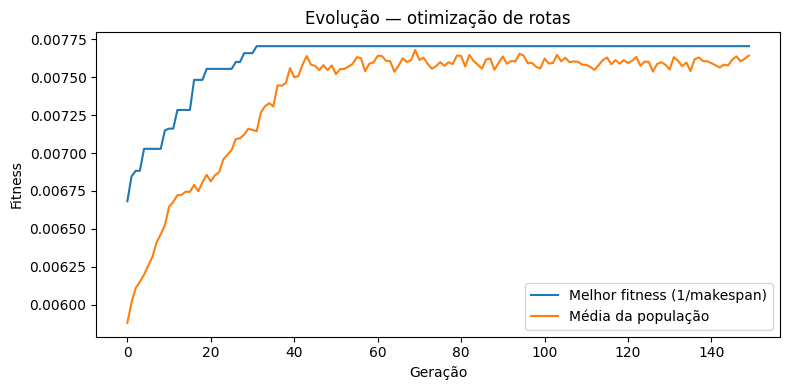

In [25]:
random.seed(42)

n_nodes = 5
sym = [[0.0] * n_nodes for _ in range(n_nodes)]
for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        d = random.uniform(5.0, 25.0)
        sym[i][j] = sym[j][i] = d
travel = TravelTimeModel(sym)

NUM_CONTAINERS = 20
# Destinos no grafo do campus (nós 1..4); ajuste aos prédios reais. `ready_time` vem do descarregamento.
dests = [1 + (i % 4) for i in range(NUM_CONTAINERS)]
ready = [float(i * 3) for i in range(NUM_CONTAINERS)]
deliveries = [
    DeliveryTask(container_id=i, destination=dests[i], ready_time=ready[i])
    for i in range(NUM_CONTAINERS)
]

print("--- Baseline (ordem 0..n-1) ---")
sol_g = optimize_routes_greedy(deliveries, travel, num_carriers=3)
print_solution_summary(sol_g, deliveries)

print("\n--- AG ---")
sol_ga, best_h, mean_h = optimize_routes_ga(
    deliveries,
    travel,
    num_carriers=3,
    population_size=100,
    generations=150,
)
print_solution_summary(sol_ga, deliveries)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_h, label="Melhor fitness (1/makespan)")
ax.plot(mean_h, label="Média da população")
ax.set_xlabel("Geração")
ax.set_ylabel("Fitness")
ax.legend()
ax.set_title("Evolução — otimização de rotas")
plt.tight_layout()
plt.show()
